## Sales Data Analysis and Forecasting using Python, Azure SQL, and Time Series Modeling

<div style="background-color:#E8F4FF; padding:15px; border-radius:10px; border-left:6px solid #2F80ED">

<h4 style="color:#2F80ED;">📊 Project Overview</h4>

<span style="font-weight:bold;">
This project focuses on extracting, analysing, and forecasting sales data from an Azure SQL Database using Python.
</span>

<br><br>

<h5 style="color:#2F80ED;">🎯 Key Objectives</h5>

<ul>
<li>Connect to an Azure SQL Database using Python and <code>pyodbc</code></li>
<li>Query and integrate data from <b>Sales</b>, <b>Invoice</b>, and <b>Product</b> tables</li>
<li>Perform Exploratory Data Analysis (EDA) to understand patterns and data quality</li>
<li>Build a time series forecasting model using <b>ARIMA</b></li>
<li>Analyse trends and predict future sales based on historical data</li>
</ul>

<br>

<span style="color:#2F80ED; font-weight:bold;">
👉 Outcome: Generate data-driven insights and forecast future sales to support business decision-making.
</span>

</div>


**The tables we will query are as follows:**

<span style="color:#2F80ED; font-weight:bold;"> Sales Table: there are 83277 sale records in this table </span>

| InvoiceNo | StockCode | Quantity | UnitPrice | InvoiceDate |
| --------- | --------- | -------- | --------- | ----------- |
| 536365    | 71053     | 6        | 3.39      | 2015-01-01  |
| 536365    | 22752     | 2        | 7.65      | 2015-01-01  |
| 536366    | 84029     | 6        | 3.39      | 2015-01-01  |
| 536366    | 21730     | 6        | 4.25      | 2015-01-01  |


This table contains the details of each sale, including the InvoiceNo, StockCode, Quantity, UnitPrice, and InvoiceDate.

The Sales table is crucial for understanding sales transactions and performing time series analysis.



Invoice Table:

This table contains information about the InvoiceNo and the Country where the transaction took place.

The Invoice table helps us track the geographical location of each sale, which is valuable for regional sales analysis.

Sample of the Invoice table:

| InvoiceNo | Country        |
| --------- | -------------- |
| 536365    | United Kingdom |
| 536366    | United Kingdom |
| 536367    | United Kingdom |
| 536368    | United Kingdom |


Product Table:

This table contains details about the products sold, including the StockCode, Product Description, and Product Category.

The Product table allows us to understand the types of products being sold, which is useful for inventory and category-based analysis.

Sample of the Product table:

| StockCode | Description                     | Product\_Category |
| --------- | ------------------------------- | ----------------- |
| 71053     | PHOTO FRAME CORNICE             | FRAME             |
| 22752     | TEA TIME TEAPOT IN GIFT BOX     | GIFT              |
| 84029     | FRENCH BLUE METAL DOOR SIGN 3   | SIGN              |
| 21730     | CERAMIC CAKE DESIGN SPOTTED MUG | MUG               |



 


### 1️⃣. Connect to Azure SQL Database

To start, pyodbc library is used to connect to the Azure SQL Database. Below is the code to establish the connection.

In [2]:
import pyodbc
import pandas as pd

# Azure SQL connection parameters
server = 'analyticsmissionready.database.windows.net'
database = 'online_sales_retailer'
username = 'analyticsdata'
password = 'Missionanalytics-2025'

# Create a connection string
connection_string = f'DRIVER={{ODBC Driver 18 for SQL Server}};SERVER={server};PORT=1433;DATABASE={database};UID={username};PWD={password}'

# Connect to the database
conn = pyodbc.connect(connection_string)

# Query to execute
query = 'SELECT * FROM dbo.Sales'

# Load the SQL query results directly into a pandas DataFrame
df_sales = pd.read_sql(query, conn)

# Display the first few rows of the dataframe
sale_records= len(df_sales)
print(f"there are {sale_records} sale records in this dataset")
df_sales.head()



/tmp/ipykernel_101/945370126.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales = pd.read_sql(query, conn)


there are 83277 sale records in this dataset


,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate
0,536365.0,71053.0,6.0,3.39,2015-01-01
1,536365.0,22752.0,2.0,7.65,2015-01-01
2,536365.0,84406.0,8.0,2.75,2015-01-01
3,536366.0,84029.0,6.0,3.39,2015-01-01
4,536366.0,21730.0,6.0,4.25,2015-01-01


### 2️⃣. Connecting and Joining Multiple Tables in the Database

First lets get the other two tables as dataframes

In [3]:
# Query to connect with the product table
query_product = 'SELECT * FROM dbo.Product'

# Load the SQL query results directly into pandas DataFrames

df_product = pd.read_sql(query_product, conn)

# Display the first few rows of each DataFrame

df_product.head()


/tmp/ipykernel_101/2344487833.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql(query_product, conn)


,StockCode,Description,Product_Category
0,71053.0,PHOTO FRAME CORNICE,FRAME
1,22752.0,TEA TIME TEAPOT IN GIFT BOX,GIFT
2,84406.0,ZINC HEARTS PLANT POT HOLDER,HOLDER
3,84029.0,FRENCH BLUE METAL DOOR SIGN 3,SIGN
4,21730.0,CERAMIC CAKE DESIGN SPOTTED MUG,MUG


In [4]:
# Query to connect with the Invoice Table
query_invoice = 'SELECT * FROM Invoice'

# Load the SQL query results directly into pandas DataFrames

df_invoice = pd.read_sql(query_invoice, conn)

# Display the first few rows of each DataFrame

df_invoice.head()

/tmp/ipykernel_101/2429307430.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_invoice = pd.read_sql(query_invoice, conn)


,InvoiceNo,Country
0,536365.0,United Kingdom
1,536366.0,United Kingdom
2,536367.0,United Kingdom
3,536368.0,United Kingdom
4,536369.0,United Kingdom


### 3️⃣. Data Joining and Merging
In order to get a comprehensive view of the data, the Sales, Invoice, and Product tables are to be merged. By joining these tables,  sale analysis along with product details and geographical information can be performed.

- Join the Sales and Invoice tables based on InvoiceNo.

- Join the resulting dataset with the Product table based on StockCode.

In [5]:
# Join Sales and Invoice tables on InvoiceNo
df_sales_invoice = pd.merge(df_sales, df_invoice, on='InvoiceNo', how='left')

# Join the resulting table with Product table on StockCode
df_full = pd.merge(df_sales_invoice, df_product, on='StockCode', how='left')

# Display the first few rows of the combined dataset (This Code Allo)
df_full.head()


,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Country,Description,Product_Category
0,536365.0,71053.0,6.0,3.39,2015-01-01,United Kingdom,PHOTO FRAME CORNICE,FRAME
1,536365.0,22752.0,2.0,7.65,2015-01-01,United Kingdom,TEA TIME TEAPOT IN GIFT BOX,GIFT
2,536365.0,84406.0,8.0,2.75,2015-01-01,United Kingdom,ZINC HEARTS PLANT POT HOLDER,HOLDER
3,536366.0,84029.0,6.0,3.39,2015-01-01,United Kingdom,FRENCH BLUE METAL DOOR SIGN 3,SIGN
4,536366.0,21730.0,6.0,4.25,2015-01-01,United Kingdom,CERAMIC CAKE DESIGN SPOTTED MUG,MUG


### 4️⃣. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is be performed to better understand the data.

**Check for Missing Values:**

In [6]:
# Check for missing values in the combined dataset
missing_values = df_full.isnull().sum()
print(f"Missing Values:\n{missing_values}")


Missing Values:
InvoiceNo           0
StockCode           0
Quantity            0
UnitPrice           0
InvoiceDate         0
Country             0
Description         0
Product_Category    0
dtype: int64


**Summary Statistics:**

In [7]:
summary_stats = df_full.describe()
print(f"Summary Statistics:\n{summary_stats}")

Summary Statistics:
           InvoiceNo     StockCode      Quantity     UnitPrice
count   83277.000000  83277.000000  83277.000000  83277.000000
mean   550244.000000  32948.774860     13.610961      3.083503
std      8013.381169  22938.831323    261.577565      5.177653
min    536365.000000  10002.000000      1.000000      0.000000
25%    543304.000000  21843.000000      2.000000      1.250000
50%    550244.000000  22470.000000      6.000000      1.950000
75%    557184.000000  22941.000000     12.000000      3.750000
max    564123.000000  90214.000000  74215.000000    295.000000


Data Types:

In [8]:
# Check the data types of the columns
print(f"Data Types:\n{df_full.dtypes}")

Data Types:
InvoiceNo           float64
StockCode           float64
Quantity            float64
UnitPrice           float64
InvoiceDate          object
Country              object
Description          object
Product_Category     object
dtype: object


**Creating the Sales Column**

In [9]:
df_full['Sales'] = df_full['Quantity'] * df_full['UnitPrice']
df_full.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Country,Description,Product_Category,Sales
0,536365.0,71053.0,6.0,3.39,2015-01-01,United Kingdom,PHOTO FRAME CORNICE,FRAME,20.34
1,536365.0,22752.0,2.0,7.65,2015-01-01,United Kingdom,TEA TIME TEAPOT IN GIFT BOX,GIFT,15.30
2,536365.0,84406.0,8.0,2.75,2015-01-01,United Kingdom,ZINC HEARTS PLANT POT HOLDER,HOLDER,22.00
3,536366.0,84029.0,6.0,3.39,2015-01-01,United Kingdom,FRENCH BLUE METAL DOOR SIGN 3,SIGN,20.34
4,536366.0,21730.0,6.0,4.25,2015-01-01,United Kingdom,CERAMIC CAKE DESIGN SPOTTED MUG,MUG,25.50


**Product Category Distribution:**

Let’s visualise the distribution of Product Categories to see which categories contribute the most to sales.

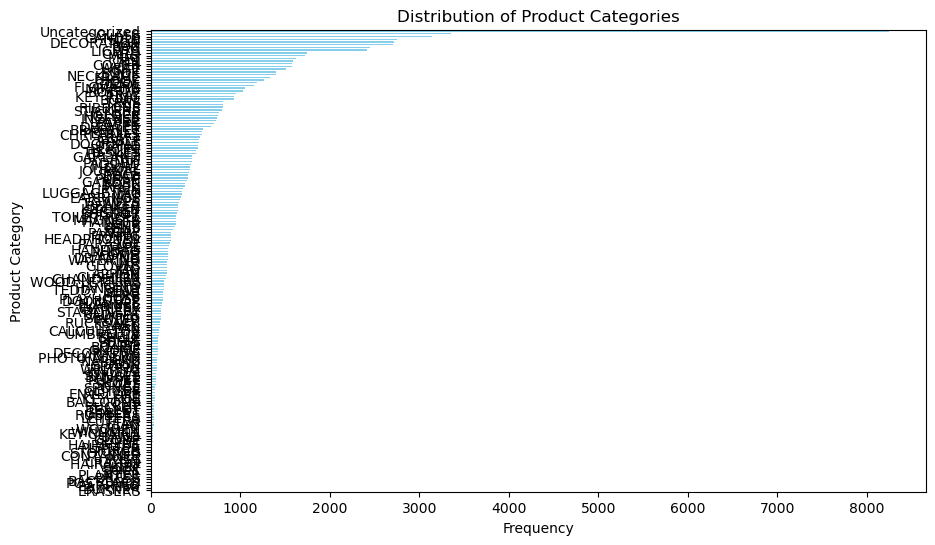

In [10]:
# Count the number of products per category
product_category_counts = df_full['Product_Category'].value_counts()


# Plot the distribution of Product Categories as a horizontal bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
product_category_counts.sort_values(ascending=True).plot(kind='barh', color='skyblue')  # Horizontal bar chart

plt.title('Distribution of Product Categories')
plt.xlabel('Frequency')
plt.ylabel('Product Category')
plt.show()



In [11]:
#Display product count by product category
product_category_counts 

Product_Category
Uncategorized    8243
GLASS            3353
CANDLE           3147
SIGN             2753
DECORATION       2722
                 ... 
BACKPACK            4
POSTCARD            4
EARRING             3
BURNER              2
ERASERS             1
Name: count, Length: 170, dtype: int64

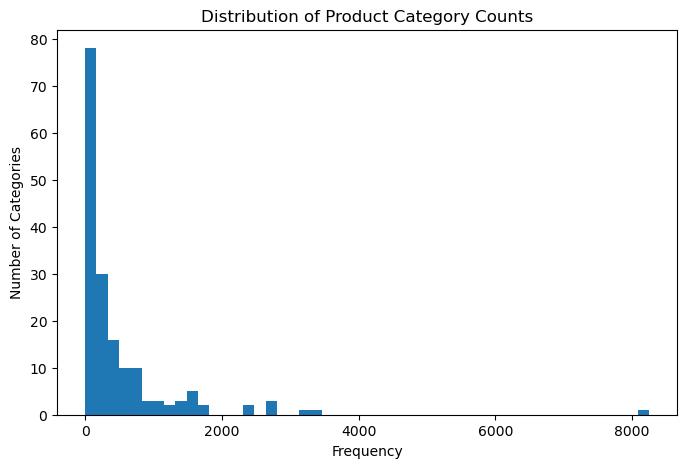

In [12]:
plt.figure(figsize=(8,5))
product_category_counts.plot(kind='hist', bins=50)

plt.title('Distribution of Product Category Counts')
plt.xlabel('Frequency')
plt.ylabel('Number of Categories')
plt.show()

<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">

👉 The dataset contains 170 product categories, indicating a highly diverse product range. However, the distribution is heavily skewed, with a small number of categories accounting for a large proportion of records, while many categories have very low frequencies. This reflects a long-tail distribution.
<br>

⚠️ A significant number of records fall under "Uncategorized", suggesting missing or incomplete product classification. This may impact the accuracy of category-level analysis and should be addressed through data cleaning or improved categorisation.


👉 The presence of many low-frequency categories suggests niche or low-demand products, while high-frequency categories represent core product segments that likely drive the majority of sales activity.

👉 Due to the large number of product categories, the full distribution chart becomes crowded and difficult to interpret. 
Narrowing down to the top 10 categories improves clarity and highlights the most significant contributors to overall activity.

</div>


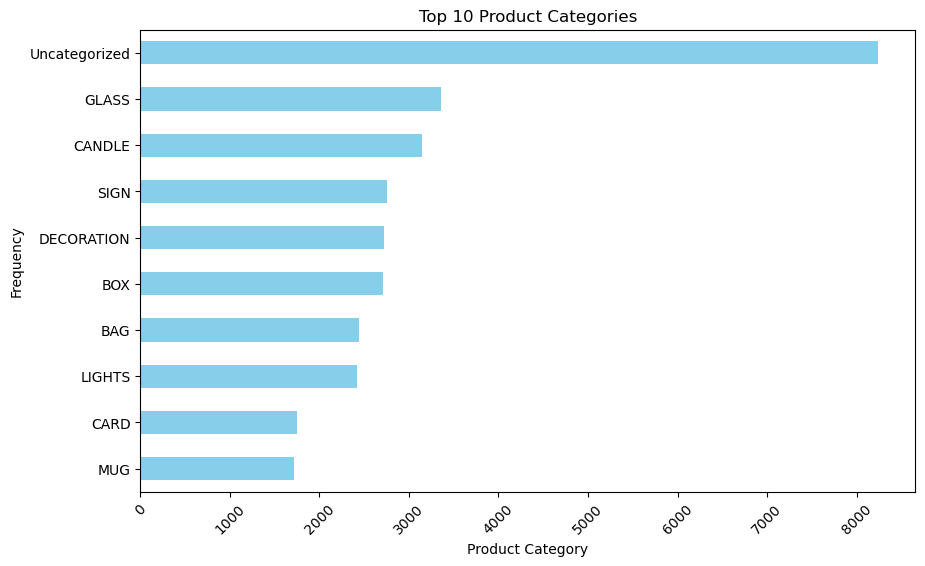

In [13]:
# Displaying Top 10 Categories
# Count the number of products per category
product_category_counts = df_full['Product_Category'].value_counts()

# Select the top 10 product categories
top_10_categories = product_category_counts.head(10)

# Plot the distribution of the top 10 Product Categories as a horizontal bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Plot


top_10_categories.sort_values(ascending=True).plot(kind='barh', color='skyblue')  # Horizontal bar chart


plt.title('Top 10 Product Categories')
plt.ylabel('Frequency')
plt.xlabel('Product Category')
plt.xticks(rotation=45)

plt.show()

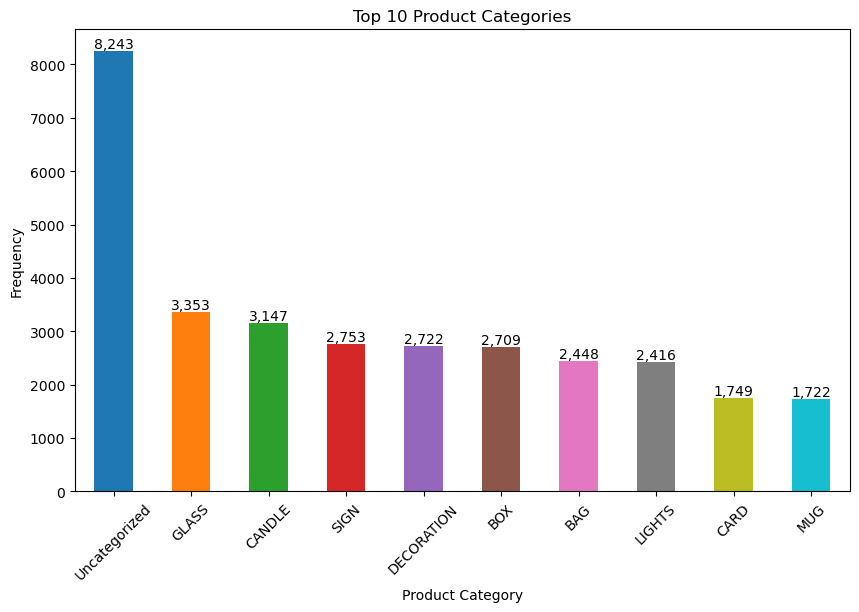

In [14]:
# Change x as product category and y as Frequency for a different look
# mix color & add data labels for style
# Count the number of products per category
product_category_counts = df_full['Product_Category'].value_counts()

# Select the top 10 product categories
top_10_categories = product_category_counts.head(10)

# Plot the distribution of the top 10 Product Categories as a horizontal bar chart
import matplotlib.pyplot as plt

sorted_data = top_10_categories.sort_values(ascending=False)

colors = plt.cm.tab10(range(len(sorted_data)))  # auto color palette

plt.figure(figsize=(10, 6))
ax = sorted_data.plot(kind='bar', color=colors)

for i, value in enumerate(sorted_data):
    ax.text(i, value, f"{value:,}", ha='center', va='bottom')

plt.title('Top 10 Product Categories')
plt.ylabel('Frequency')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.show()

<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">
<strong>
👉 The distribution highlights a strong concentration in a few categories, with “Uncategorized” dominating the dataset.  This suggests potential data quality issues that may impact analysis. </strong>

 Among the classified categories, GLASS, CANDLE, and SIGN appear to be key product segments, which may represent core areas of business activity.

</div>

**Sales by Country:**

Let’s visualise sales by country to see how sales differ across regions.

In [15]:
# Create Sales column
df_full['Sales'] = df_full['Quantity'] * df_full['UnitPrice']
df_full.head()

# Create Total Sales Revenue by Country
from IPython.display import display, HTML
sales_by_country = (
    df_full
    .groupby('Country', as_index=False)['Sales']
    .sum()
    .sort_values(by='Sales', ascending=False)
)


display(HTML("<h4 style='color:#2F80ED;'>🌍 Total Sales by Country</h4>"))
display(sales_by_country)

,Country,Sales
36,United Kingdom,1732491.93
14,Germany,55571.41
13,France,34498.91
24,New Zealand,31124.57
4,Belgium,10387.45
23,Netherlands,9678.04
31,Spain,8307.82
1,Australia,5979.46
26,Poland,5120.76
27,Portugal,4918.57


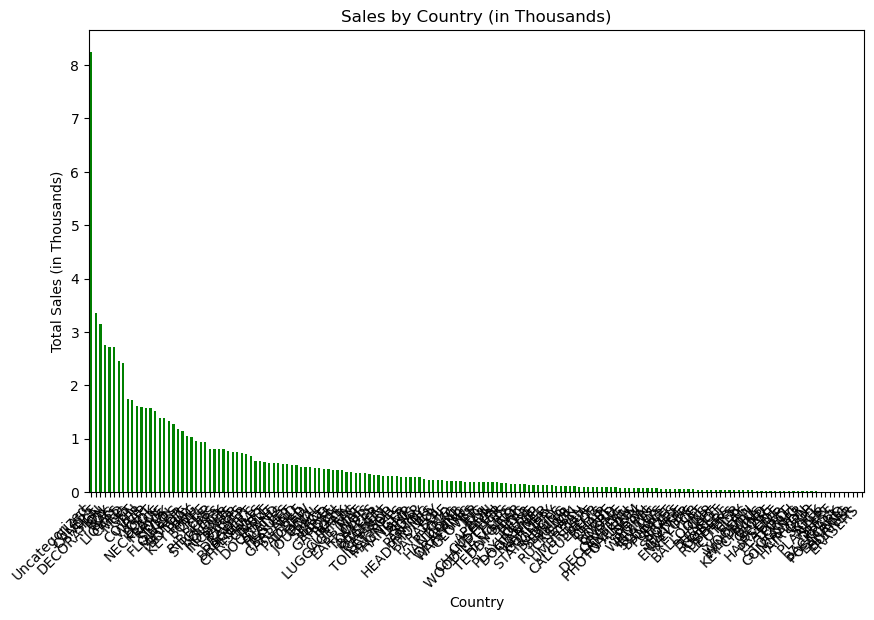

In [16]:
# Group by Country and sum Sales
sales_by_country = df_full['Product_Category'].value_counts().sort_values(ascending=False)

# Convert sales values to thousands
sales_by_country_in_thousands = sales_by_country / 1000 # Convert to Thousands

# Plot sales by country
plt.figure(figsize=(10, 6))
sales_by_country_in_thousands.plot(kind='bar', color='green')
plt.title('Sales by Country (in Thousands)')
plt.xlabel('Country')
plt.ylabel('Total Sales (in Thousands)')
plt.xticks(rotation=45, ha='right')
plt.show()

<div style="background-color: #ddebf9ff; padding:10px; border-radius:8px; border-left:5px solid #2F80ED; color: #031730ff">

👉 The full distribution chart becomes crowded and difficult to interpret due to the large number of countries. 
Focusing on the top 10 countries improves clarity and highlights the most significant contributors to overall activity.
</span>
</div>

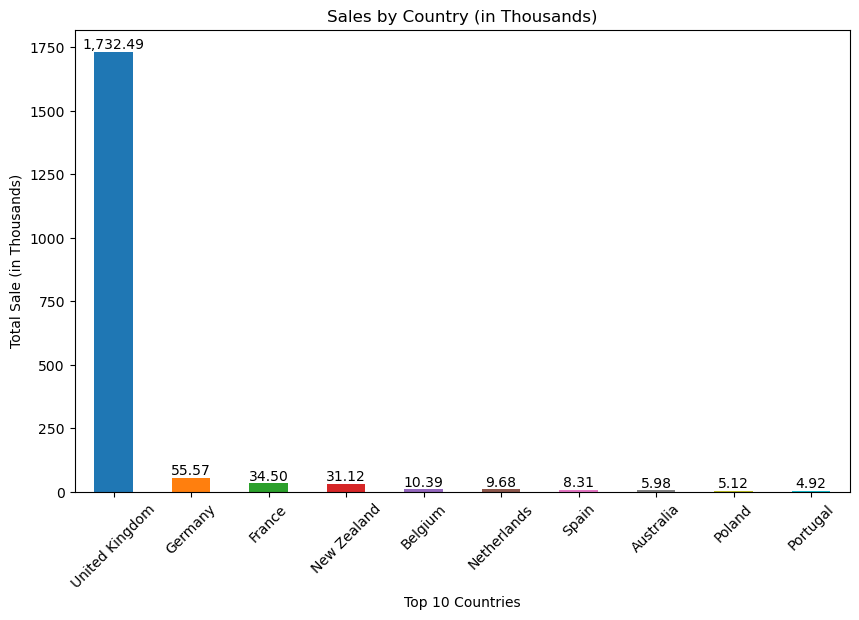

In [17]:
# Group by Country and sum Sales

sales_by_country = df_full.groupby('Country')['Sales'].sum().sort_values(ascending=False)

# Convert sales values to thousands
sales_by_country_in_thousands = sales_by_country / 1000  # Convert to thousands

# Select the top 10 product categories
top_10_countries = sales_by_country_in_thousands.head(10)

sorted_data = top_10_countries.sort_values(ascending=False)

colors = plt.cm.tab10(range(len(sorted_data)))  # auto color palette

plt.figure(figsize=(10, 6))
ax = sorted_data.plot(kind='bar', color=colors)

# Plot sales by top 10 countries

ax = sorted_data.plot(kind='bar', color=colors)

for i, value in enumerate(sorted_data):
    ax.text(i, value, f"{value:,.2f}", ha='center', va='bottom')

plt.title('Sales by Country (in Thousands)')
plt.ylabel('Total Sale (in Thousands)')
plt.xlabel('Top 10 Countries')
plt.xticks(rotation=45)
plt.show()

In [18]:
#calculate percentage of the sale by the dominant country UK
uk_sales = sales_by_country.loc['United Kingdom']
total_sales = sales_by_country.sum()

uk_pct = uk_sales / total_sales * 100
rest_pct = 100 - uk_pct

print(f"UK Contribution: {uk_pct:.2f}%")
print(f"Rest of Countries: {rest_pct:.2f}%")

UK Contribution: 89.98%
Rest of Countries: 10.02%


<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">
<strong>
👉 The chart shows that the United Kingdom dominates sales by a significant margin, standing out as a clear outlier compared to all other countries. There is a sharp decline in sales after the UK, with countries such as Germany, France, and New Zealand contributing moderate amounts, while the remaining countries have relatively low and similar sales levels.
<br><br>
👉 Quantitatively, the United Kingdom contributes approximately 91% of total sales among the top 10 countries, while all other countries combined account for only about 9%. This highlights a highly concentrated sales distribution.
<br><br>
👉 This strong reliance on a single market suggests both a well-established core business and a potential risk. While the UK represents a key revenue driver, there is a clear opportunity to expand into other regions to achieve a more balanced and diversified market presence.
<br><br>
⚠️ The large gap between the UK and other countries also compresses the visual scale, making differences among smaller markets less visible.

</div>


In [19]:
# Sort countries by sales (descending)
sales_sorted = sales_by_country.sort_values(ascending=False)

# Calculate percentage contribution
percentage = sales_sorted / sales_sorted.sum() * 100

# Calculate cumulative percentage
cumulative_pct = percentage.cumsum()

# Combine into one table
pareto_df = pd.DataFrame({
    'Sales': sales_sorted,
    'Percentage (%)': percentage,
    'Cumulative (%)': cumulative_pct
})

# Format to 2 decimal places
pareto_df['Percentage (%)'] = pareto_df['Percentage (%)'].round(2)
pareto_df['Cumulative (%)'] = pareto_df['Cumulative (%)'].round(2)

display(pareto_df.head(10))

,Sales,Percentage (%),Cumulative (%)
Country,,,
United Kingdom,1732491.93,89.98,89.98
Germany,55571.41,2.89,92.86
France,34498.91,1.79,94.66
New Zealand,31124.57,1.62,96.27
Belgium,10387.45,0.54,96.81
Netherlands,9678.04,0.50,97.31
Spain,8307.82,0.43,97.75
Australia,5979.46,0.31,98.06
Poland,5120.76,0.27,98.32


<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">
<strong>
👉 A Pareto analysis shows that a very small number of countries contribute the majority of total sales. Notably, the United Kingdom alone accounts for approximately 91% of sales, and the top few countries together contribute over 95%. This reflects a highly concentrated distribution, far exceeding the typical 80/20 pattern.
<br><br>
👉 This indicates that business performance is heavily dependent on a limited number of markets. While this highlights strong dominance in key regions, it also suggests an opportunity to expand into underperforming countries to achieve a more balanced and resilient sales portfolio.
</strong>
</div>

### 5️⃣. Time Series Forecasting Using ARIMA

After performing the exploratory analysis, the next step is forecasting sales using ARIMA with the following steps:

**Prepare the Data:** Aggregating the sales data by month.

**Train-Test Split:** Splitting the data into 80% training and 20% testing.

**Apply ARIMA:** Fitting an ARIMA model to forecast future sales.


**Important Note:**
<div style="background-color:#E8F4FF"> Timestamp is very crucial for time series forecasting

A **timestamp** represents a specific point in time (date + time), stored in pandas as `datetime64[ns]`.

In below workflow:
- Data is first grouped by **Period (month)** → represents a time range (e.g., `2025-01`)
- Then converted to **Timestamp** → represents a specific date (e.g., `2025-01-01 00:00:00`)

This conversion is important because timestamps are required for:
- time series plotting (Matplotlib)
- forecasting models (e.g., ARIMA, Prophet)
- accurate filtering and analysis

👉 In short:
- **Period = time span**
- **Timestamp = exact point in time**
</div>

<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">
<strong>
👉 To analyse sales trends over time and predict future performance, the transactional data is aggregated into monthly sales and modelled using a time series forecasting appoach.
</strong>
</div>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Group by InvoiceDate and sum the sales to get monthly sales

# Convert 'InvoiceDate' column from object (text) to datetime format
df_full['InvoiceDate'] = pd.to_datetime(df_full['InvoiceDate'])

## Group data by month (convert date to monthly period) and sum total Sales for each month
#df_monthly_sales = df_full.groupby(df_full['InvoiceDate'].dt.to_period('M')).agg({'Sales': 'sum'}).reset_index()


df_monthly_sales = df_full.groupby(
    df_full['InvoiceDate'].dt.to_period('M')
).agg({'Sales': 'sum'}).reset_index()

# Convert the period to a datetime object for plotting
# Convert monthly period format (e.g., 2025-01) back to datetime (e.g., 2025-01-01) for plotting
# A timestamp is simply a specific point in time stored in a standard date-time format.
df_monthly_sales['InvoiceDate'] = df_monthly_sales['InvoiceDate'].dt.to_timestamp()

# Display the first few rows of the dataset
print("\nMonthly Sales Data:")
print(df_monthly_sales.head())




Monthly Sales Data:
  InvoiceDate     Sales
0  2015-01-01  42201.92
1  2015-02-01  37842.65
2  2015-03-01  39113.76
3  2015-04-01  18894.97
4  2015-05-01  26820.78


<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">
<strong>
👉 The monthly sales trend shows fluctuations over time, indicating variability in demand and potential seasonality. This pattern suggests that past sales behaviour can be used to predict future performance using time series models.
</strong>
</div>

In [21]:
# Split the data into train and test sets (80% training, 20% testing)
train_size = int(len(df_monthly_sales) * 0.8)
train_size = int(len(df_monthly_sales) * 0.8)
train_data, test_data = df_monthly_sales[:train_size], df_monthly_sales[train_size:]

# Display the train and test data
print("\nTraining Data:")
print(train_data.head())
print("\nTesting Data:")
print(test_data.head())


Training Data:
  InvoiceDate     Sales
0  2015-01-01  42201.92
1  2015-02-01  37842.65
2  2015-03-01  39113.76
3  2015-04-01  18894.97
4  2015-05-01  26820.78

Testing Data:
   InvoiceDate     Sales
38  2018-03-01  28538.51
39  2018-04-01  51119.61
40  2018-05-01  30930.23
41  2018-06-01  27947.65
42  2018-07-01  34422.94


In [22]:
print("Number of training records:", len(train_data))
print("Number of testing records:", len(test_data))

Number of training records: 38
Number of testing records: 10



<div style="background-color:#E8F4FF"> 
<strong>Using ARIMA Model for Monthly Sales Forecasting </strong>

This code builds and evaluates an <strong>ARIMA (AutoRegressive Integrated Moving Average) </strong> model to forecast future sales based on historical data. “ARIMA is a time series forecasting model that combines autoregression, differencing, and moving averages to capture patterns in historical data and predict future values. 

👉 The ARIMA model was configured with (p=12, d=1, q=1), where p represents the number of lag observations, d controls differencing to remove trend, and q models the error term. While ARIMA does not explicitly model seasonality, using multiple lags helps capture temporal patterns in the data.

There are 2 models for ARIMA:

- Model 1 removes trend first (d=1)

- Model 2 keeps the original series unchanged (d=0)

<strong> This difference affects how the model handles trend and stationarity.</strong>



<div style="background-color:#E8F4FF"> <strong>- Model 1 removes trend first (d=1) </strong>

model_arima = ARIMA(train_data['Sales'], order=(12, 1, 1))
model_arima_fit = model_arima.fit()

train_data['Sales'] → input time series (monthly sales)

order=(p, d, q):

p = 12 → uses last 12 periods (months) → attempts to capture yearly pattern

d = 1 → differencing applied once to make data stationary

q = 1 → uses 1 lag of forecast error (moving average component)

👉 The model learns patterns (trend + past dependencies) from training data.
</div>

/home/trusted-service-user/jupyter-env/python3.11/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


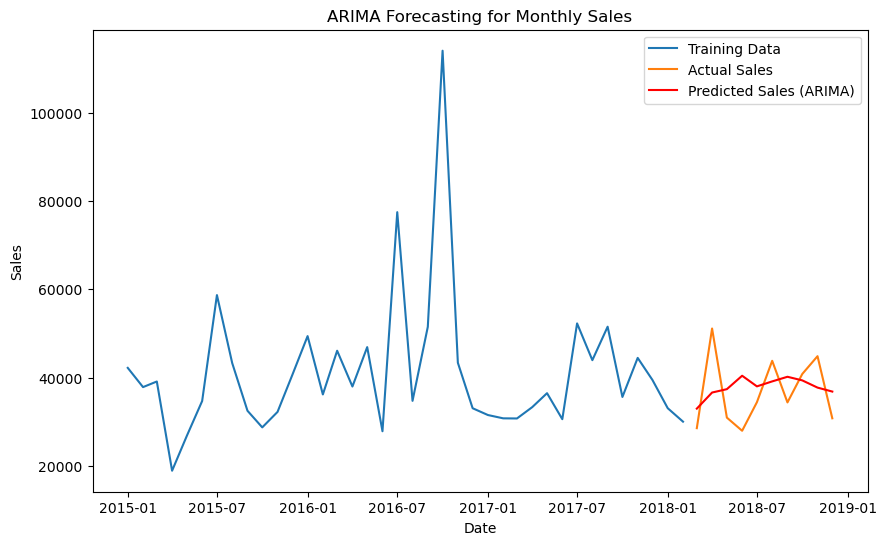

In [23]:
# Model 1

from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (p=12, d=1, q=1) -> Non-seasonal ARIMA with p=12 for seasonality capture
model_arima = ARIMA(train_data['Sales'], order=(12, 1, 1))  # p=12, d=1, q=0
model_arima_fit = model_arima.fit()

# Forecast the next 10 months of sales
forecast_arima = model_arima_fit.forecast(steps=len(test_data))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train_data['InvoiceDate'], train_data['Sales'], label='Training Data')
plt.plot(test_data['InvoiceDate'], test_data['Sales'], label='Actual Sales')
plt.plot(test_data['InvoiceDate'], forecast_arima, label='Predicted Sales (ARIMA)', color='red')
plt.title('ARIMA Forecasting for Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


<div style="background-color:#E8F4FF"> 
<strong> Model 2 </strong> 

- keeps the original series unchanged (d=0)

- Meaning it uses the same sales data but does not difference the series before fitting 

</div>

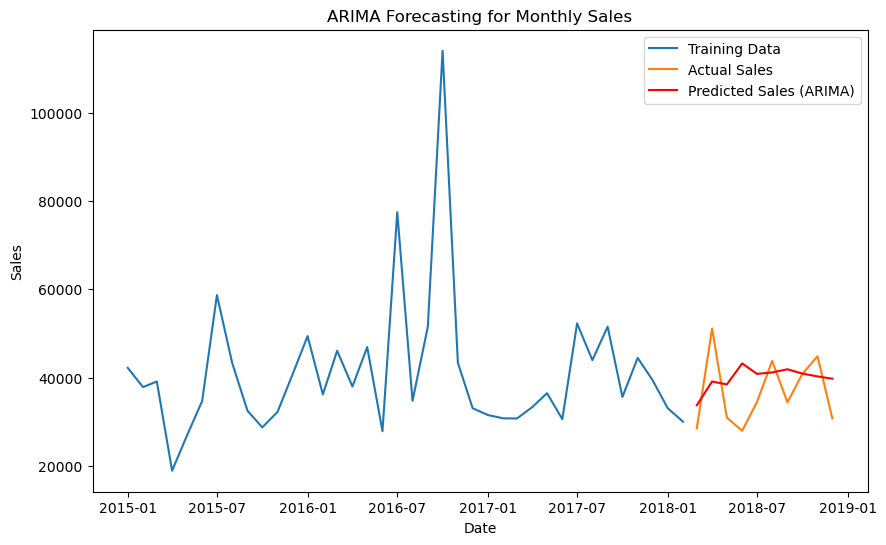

In [24]:
# Model 2

from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (p=12, d=0, q=1) -> Non-seasonal ARIMA with p=12 for seasonality capture
model_arima_2 = ARIMA(train_data['Sales'], order=(12, 0, 1))  # p=5, d=1, q=0
model_arima_fit_2 = model_arima_2.fit()

# Forecast the next 10 months of sales
forecast_arima_2 = model_arima_fit_2.forecast(steps=len(test_data))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train_data['InvoiceDate'], train_data['Sales'], label='Training Data')
plt.plot(test_data['InvoiceDate'], test_data['Sales'], label='Actual Sales')
plt.plot(test_data['InvoiceDate'], forecast_arima_2, label='Predicted Sales (ARIMA)', color='red')
plt.title('ARIMA Forecasting for Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


**Summary of the two models**
🔹 Key Differences

| Model | Order | Key Behavior |
|------|------|-------------|
| **Model 1** | (12, 1, 1) | Applies differencing → removes trend |
| **Model 2** | (12, 0, 1) | No differencing → keeps original data |



## 6️⃣. Evaluate the Models Using RMSE
Let’s evaluate the models’ performance by calculating the RMSE (Root Mean Squared Error) between the actual and forecasted values.

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE for the ARIMA model with seasonal parameters
rmse_arima_model_1 = np.sqrt(mean_squared_error(test_data['Sales'], forecast_arima))
print(f"ARIMA RMSE (Monthly with p=12 and d=1 for seasonality): {rmse_arima_model_1}")

rmse_arima_model_2 = np.sqrt(mean_squared_error(test_data['Sales'], forecast_arima_2))
print(f"ARIMA RMSE (Monthly with p=12 and d=0 for seasonality): {rmse_arima_model_2}")


ARIMA RMSE (Monthly with p=12 and d=1 for seasonality): 7648.75542934181
ARIMA RMSE (Monthly with p=12 and d=0 for seasonality): 8165.2173053619645


<div style="background-color:#E8F4FF"> <strong> ARIMA Model Evaluation (RMSE Summary)</strong>
<p>
The above code evaluates the performance of two ARIMA models by calculating the **Root Mean Squared Error (RMSE)** between actual and predicted sales.

- Uses `mean_squared_error` to compute prediction errors  
- Applies `np.sqrt()` to convert MSE → RMSE  
<strong> 🔹 What RMSE does </strong>
- Measures the average difference between **actual** and **predicted** values  
- Expressed in the same unit as Sales  
- Penalizes larger errors more heavily  

<strong> 🔹 What the code compares </strong>
- **Model 1** → predictions: `forecast_arima1`  
- **Model 2** → predictions: `forecast_arima_2`  
- Both are compared against: `test_data['Sales']`

<strong>🔹 Key Insight </strong>
- **Lower RMSE = better model performance**
- Used to determine which ARIMA model predicts sales more accurately

<div style="background-color:#E8F4FF; padding:10px; border-radius:8px; border-left:5px solid #2F80ED;">
<span style="color:#2F80ED; font-weight:bold;">
👉 Based on RMSE evaluation, Model 1 demonstrates superior forecasting accuracy on unseen (test) data, making it the preferred model for this analysis.
<br><br>
👉 Model 1 performs better because differencing (d=1) helps stabilise the time series by removing trend, leading to improved prediction accuracy compared to Model 2.
</span>
</span>
</div>


## 7️⃣. Display Actual vs Predicted Sales

In [26]:
# Create a DataFrame to show actual vs predicted values
results_df_arima = pd.DataFrame({
    'Actual Sales': test_data['Sales'],
    'Predicted Sales_Model1': forecast_arima,
    'Predicted Sales_Model2': forecast_arima_2,
})

# Display the results
print("\nActual vs Predicted Sales (Monthly with ARIMA):")
print(results_df_arima.head())



Actual vs Predicted Sales (Monthly with ARIMA):
    Actual Sales  Predicted Sales_Model1  Predicted Sales_Model2
38      28538.51            32966.849978            33729.108161
39      51119.61            36614.006436            39115.262510
40      30930.23            37376.849136            38448.345804
41      27947.65            40418.770257            43212.803307
42      34422.94            38009.837741            40843.103804


<div style="background-color:#FFF4E5; padding:10px; border-radius:8px; border-left:5px solid #F2994A;">
<span style="font-weight:bold;">
⚠️ As ARIMA does not explicitly model seasonal patterns, future improvements could include using SARIMA to better capture monthly seasonality.
</span>
</div>

## 8️⃣. Forecasting Future Sale 
<div style="background-color:#E8F4FF; padding:15px; border-radius:10px; border-left:6px solid #2F80ED">

From the evaluation, ARIMA Model 1 demonstrates better performance for this dataset. Model evaluation is essential as it enables data analysts to select the most appropriate forecasting model and improve prediction accuracy.

However, evaluating models is only part of the process. To generate future insights, an additional step is required: actual forecasting.

<strong>Below is how to apply ARIMA Model 1 (12, 1, 1) to predict future sales:</strong>

</div>

Future Sales Forecast with Confidence Interval:
  InvoiceDate  Forecasted_Sales  Lower_Bound  Upper_Bound
0  2019-01-01          39993.14      9302.82     70683.46
1  2019-02-01          38755.38      7268.21     70242.55
2  2019-03-01          35663.46      4024.04     67302.88
3  2019-04-01          35375.96      3059.27     67692.65
4  2019-05-01          37459.51      4993.59     69925.43
5  2019-06-01          36231.58      3381.35     69081.80


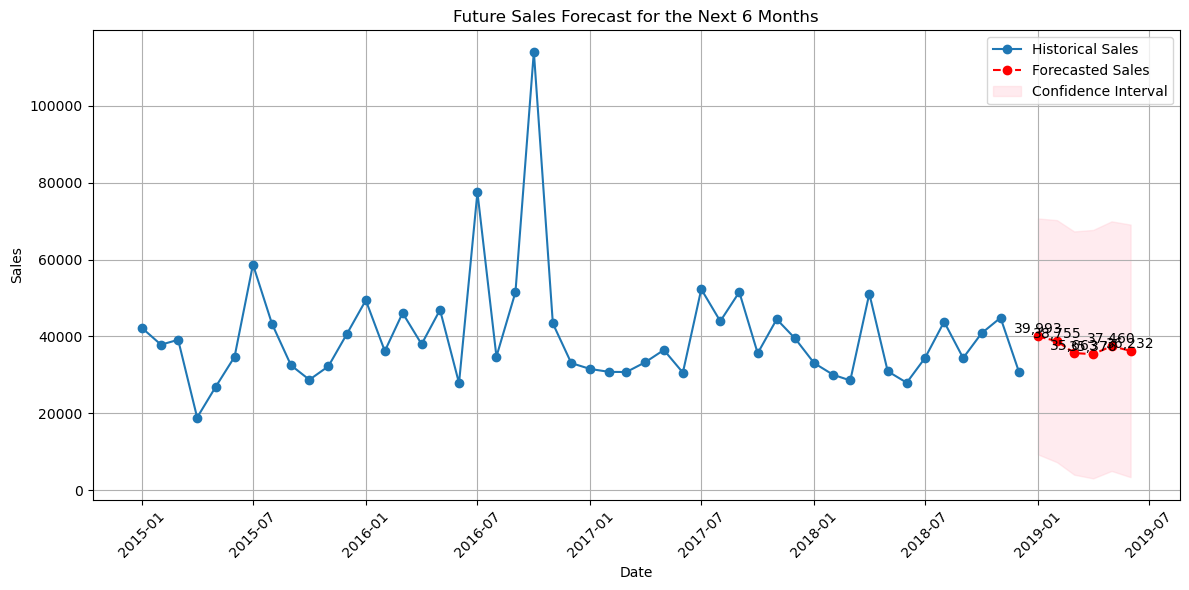

In [29]:
# ============================================================
# Real Future Sales Forecasting using ARIMA with Confidence Interval
# ------------------------------------------------------------
# This code:
# 1. Prepares monthly sales data
# 2. Trains the final ARIMA model on the full dataset
# 3. Forecasts the next 6 months of sales
# 4. Generates confidence intervals for the forecast
# 5. Displays forecasted values
# 6. Plots historical sales, forecasted sales, and confidence interval
# ============================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------------------------------------
# Step 1: Convert InvoiceDate to datetime
# ------------------------------------------------------------
df_full['InvoiceDate'] = pd.to_datetime(df_full['InvoiceDate'])

# ------------------------------------------------------------
# Step 2: Create Sales column if it does not already exist
# ------------------------------------------------------------
# Uncomment this line if Sales has not been created yet
# df_full['Sales'] = df_full['Quantity'] * df_full['UnitPrice']

# ------------------------------------------------------------
# Step 3: Aggregate transaction data into monthly sales
# ------------------------------------------------------------
df_monthly_sales = (
    df_full
    .groupby(df_full['InvoiceDate'].dt.to_period('M'))
    .agg({'Sales': 'sum'})
    .reset_index()
)

# ------------------------------------------------------------
# Step 4: Convert period to timestamp for plotting and forecasting
# ------------------------------------------------------------
df_monthly_sales['InvoiceDate'] = df_monthly_sales['InvoiceDate'].dt.to_timestamp()

# ------------------------------------------------------------
# Step 5: Fit the final ARIMA model on the full monthly sales data
# ------------------------------------------------------------
model_final = ARIMA(df_monthly_sales['Sales'], order=(12, 1, 1))
model_final_fit = model_final.fit()

# ------------------------------------------------------------
# Step 6: Forecast future sales for the next 6 months
# ------------------------------------------------------------
forecast_steps = 6
forecast_result = model_final_fit.get_forecast(steps=forecast_steps)

# Predicted mean forecast values
future_forecast = forecast_result.predicted_mean

# Confidence interval bounds
conf_int = forecast_result.conf_int()

# ------------------------------------------------------------
# Step 7: Create future monthly dates
# ------------------------------------------------------------
last_date = df_monthly_sales['InvoiceDate'].iloc[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=forecast_steps + 1,
    freq='MS'
)[1:]

# ------------------------------------------------------------
# Step 8: Create a forecast DataFrame
# ------------------------------------------------------------
df_forecast = pd.DataFrame({
    'InvoiceDate': future_dates,
    'Forecasted_Sales': future_forecast.values,
    'Lower_Bound': conf_int.iloc[:, 0].values,
    'Upper_Bound': conf_int.iloc[:, 1].values
})

# ------------------------------------------------------------
# Step 9: Format forecast values
# ------------------------------------------------------------
df_forecast['Forecasted_Sales'] = df_forecast['Forecasted_Sales'].round(2)
df_forecast['Lower_Bound'] = df_forecast['Lower_Bound'].round(2)
df_forecast['Upper_Bound'] = df_forecast['Upper_Bound'].round(2)

# ------------------------------------------------------------
# Step 10: Display forecasted values
# ------------------------------------------------------------
print("Future Sales Forecast with Confidence Interval:")
print(df_forecast)

# ------------------------------------------------------------
# Step 11: Plot historical sales, future forecast, and confidence interval
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot actual historical monthly sales
plt.plot(
    df_monthly_sales['InvoiceDate'],
    df_monthly_sales['Sales'],
    label='Historical Sales',
    marker='o'
)

# Plot forecasted future sales
plt.plot(
    df_forecast['InvoiceDate'],
    df_forecast['Forecasted_Sales'],
    label='Forecasted Sales',
    color='red',
    linestyle='--',
    marker='o'
)

# Plot confidence interval
plt.fill_between(
    df_forecast['InvoiceDate'],
    df_forecast['Lower_Bound'],
    df_forecast['Upper_Bound'],
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

# Add data labels for forecast values
for i, value in enumerate(df_forecast['Forecasted_Sales']):
    plt.text(
        df_forecast['InvoiceDate'].iloc[i],
        value,
        f"{value:,.0f}",
        ha='center',
        va='bottom'
    )

# Add title and labels
plt.title('Future Sales Forecast for the Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()

<div style="background-color:#FFF4E5; padding:10px; border-radius:8px; border-left:5px solid #F2994A;">

👉 The shaded area represents the confidence interval, showing the range within which future sales are expected to fall. A wider interval indicates greater uncertainty in the forecast, particularly for periods further into the future.
<br><br>

👉 The forecast shows an initial decline in sales, followed by a modest recovery, indicating short-term fluctuations but overall stability. This suggests a need for targeted strategies to stimulate growth and mitigate potential downturns in the coming months.
<br><br>
⚠️ Although ARIMA (12, 1, 1) provides a useful baseline forecast, it remains a non-seasonal model. The confidence interval improves the interpretation of forecast uncertainty, but it does not address seasonality. For monthly sales data, SARIMA would be a stronger next-step model to better capture recurring seasonal patterns.
</span>
</span>
</div>

### 📌 Conclusion
<div style="background-color:#E8F4FF; padding:15px; border-radius:10px; border-left:6px solid #2F80ED">

This notebook presents an end-to-end analysis and forecasting of sales data using real transactional data from an Azure SQL Database.

- Data was queried and integrated from the **Sales**, **Invoice**, and **Product** tables  
- **Exploratory Data Analysis (EDA)** identified key patterns, including skewed product category distribution and a strong concentration of sales in the United Kingdom  
- A **time series forecasting model using ARIMA** was developed to predict future sales  
- Model performance was evaluated using **RMSE**, and forecasting results were enhanced with **confidence intervals** to quantify uncertainty  

The analysis reveals that sales are highly concentrated in a single market, with the United Kingdom contributing the majority of total revenue. Pareto analysis further confirms that a small number of markets drive most of the business, indicating both strong core performance and potential concentration risk.

The forecast suggests short-term fluctuations with overall stable performance, while the confidence interval highlights increasing uncertainty over time. Although ARIMA provides a solid baseline, its limitation in capturing seasonality suggests that more advanced models such as **SARIMA** could further improve forecasting accuracy.

Overall, this project demonstrates how data analysis and time series forecasting can generate actionable insights to support **data-driven decision-making**, particularly in demand planning, market expansion, and strategic business planning.

</div>
